# Loan Approval Prediction

Predicting whether a loan application gets approved, using applicant, financial and loan details.

Plan: clean the data, do proper EDA, build a leak-free preprocessing pipeline, compare 7 models with cross-validation, tune the best ones, and only then look at the test set.

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (confusion_matrix, classification_report, roc_auc_score, roc_curve, ConfusionMatrixDisplay)

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 30)

## 1. Loading the data

In [2]:
df = pd.read_csv("loan_approval_data.csv")
print(df.shape)
df.head()

(1000, 20)


,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    str    
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    str    
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    str    
 15  Property_Area       950 non-null    str    
 16  Education_Level   

## 2. Missing values

In [4]:
missing = df.isnull().sum()
print(missing)
print("rows with at least one missing value:", df.isnull().any(axis=1).sum())

Applicant_ID          50
Applicant_Income      50
Coapplicant_Income    50
Employment_Status     50
Age                   50
Marital_Status        50
Dependents            50
Credit_Score          50
Existing_Loans        50
DTI_Ratio             50
Savings               50
Collateral_Value      50
Loan_Amount           50
Loan_Term             50
Loan_Purpose          50
Property_Area         50
Education_Level       50
Gender                50
Employer_Category     50
Loan_Approved         50
dtype: int64
rows with at least one missing value: 649


In [ ]:
# rows without a label can't be used for training or testing, so drop them
df = df.dropna(subset=["Loan_Approved"]).reset_index(drop=True)

# id column has no information
df = df.drop(columns="Applicant_ID")

df["Loan_Approved"] = (df["Loan_Approved"] == "Yes").astype(int)
print(df.shape)
df["Loan_Approved"].value_counts()

(950, 19)


Loan_Approved
0    652
1    298
Name: count, dtype: int64

## 3. EDA

### Target balance

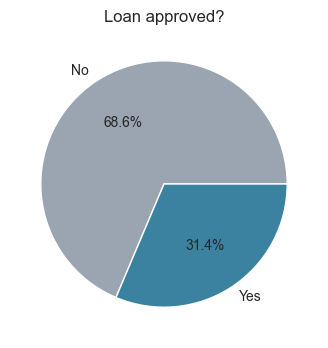

In [6]:
counts = df["Loan_Approved"].value_counts()
plt.figure(figsize=(4, 4))
plt.pie(counts, labels=["No", "Yes"], autopct="%1.1f%%", colors=["#9aa5b1", "#3b82a0"])
plt.title("Loan approved?")
plt.show()

### Numeric features

In [7]:
num_cols = df.select_dtypes(include="number").drop(columns="Loan_Approved").columns.tolist()
cat_cols = df.select_dtypes(exclude="number").columns.tolist()
print(num_cols)
print(cat_cols)
df[num_cols].describe().T.round(2)

['Applicant_Income', 'Coapplicant_Income', 'Age', 'Dependents', 'Credit_Score', 'Existing_Loans', 'DTI_Ratio', 'Savings', 'Collateral_Value', 'Loan_Amount', 'Loan_Term']
['Employment_Status', 'Marital_Status', 'Loan_Purpose', 'Property_Area', 'Education_Level', 'Gender', 'Employer_Category']


,count,mean,std,min,25%,50%,75%,max
Applicant_Income,902.0,10847.02,5064.21,2009.0,6742.00,10452.50,15174.25,19988.0
Coapplicant_Income,902.0,5061.61,2937.41,1.0,2469.75,5143.00,7589.75,9996.0
Age,902.0,40.04,11.19,21.0,31.00,40.00,49.00,59.0
Dependents,903.0,1.46,1.10,0.0,1.00,1.00,2.00,3.0
Credit_Score,902.0,675.11,71.33,550.0,616.00,677.00,735.00,799.0
Existing_Loans,901.0,1.95,1.41,0.0,1.00,2.00,3.00,4.0
DTI_Ratio,903.0,0.35,0.14,0.1,0.22,0.34,0.48,0.6
Savings,901.0,9966.30,5859.62,73.0,4761.00,9910.00,15052.00,19996.0
Collateral_Value,901.0,24701.88,14328.91,36.0,12634.00,24059.00,36843.00,49954.0
Loan_Amount,903.0,20455.90,11511.44,1015.0,9772.50,21282.00,30138.50,39995.0


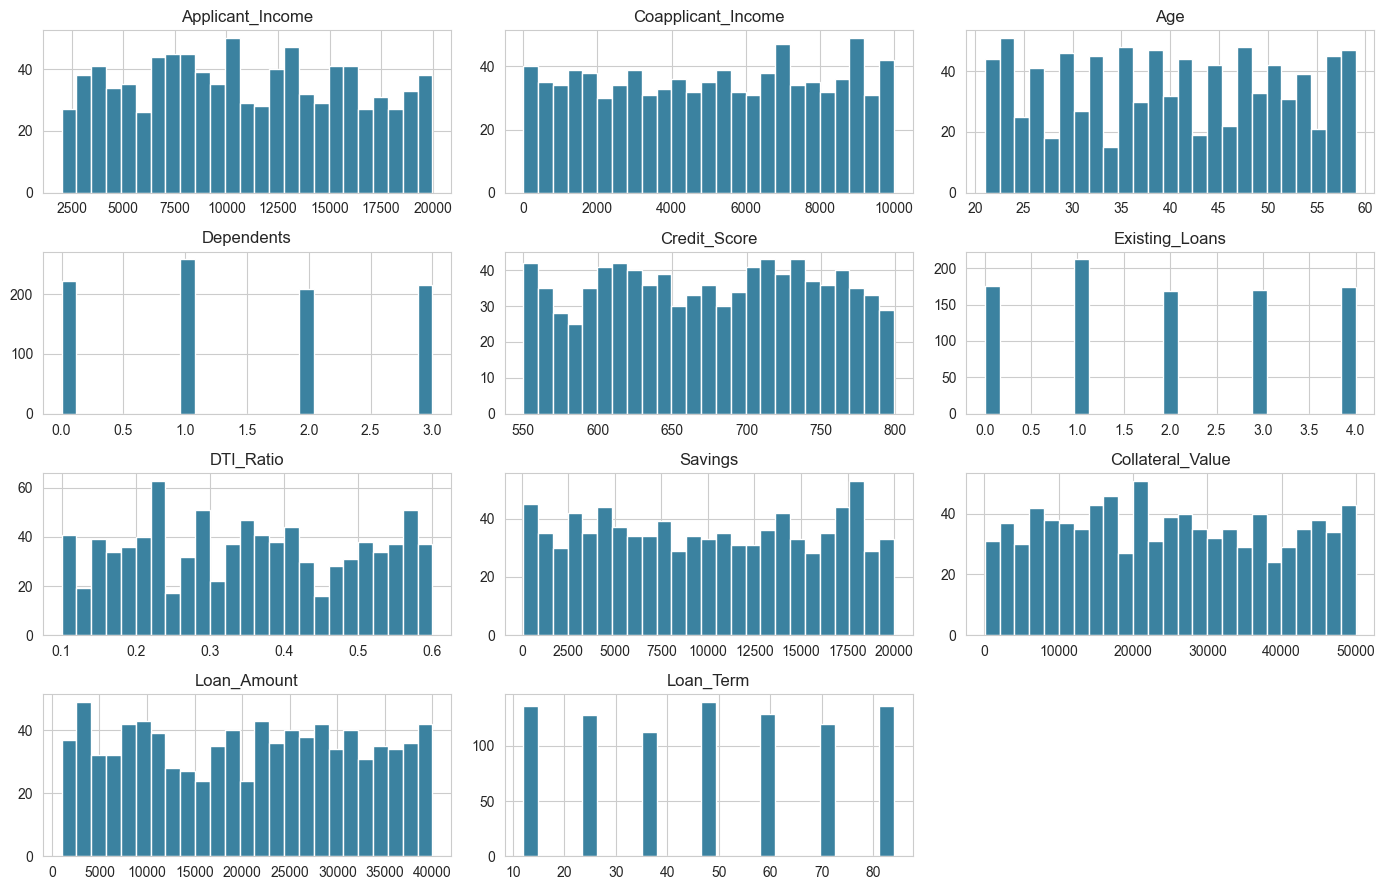

Credit_Score         -0.05
Coapplicant_Income   -0.04
Age                  -0.02
Loan_Amount          -0.02
Loan_Term            -0.01
Savings               0.01
DTI_Ratio             0.06
Applicant_Income      0.07
Collateral_Value      0.08
Dependents            0.08
Existing_Loans        0.09
dtype: float64


In [8]:
df[num_cols].hist(bins=25, figsize=(14, 9), color="#3b82a0", edgecolor="white")
plt.tight_layout()
plt.show()

print(df[num_cols].skew().round(2).sort_values())

### Features vs approval

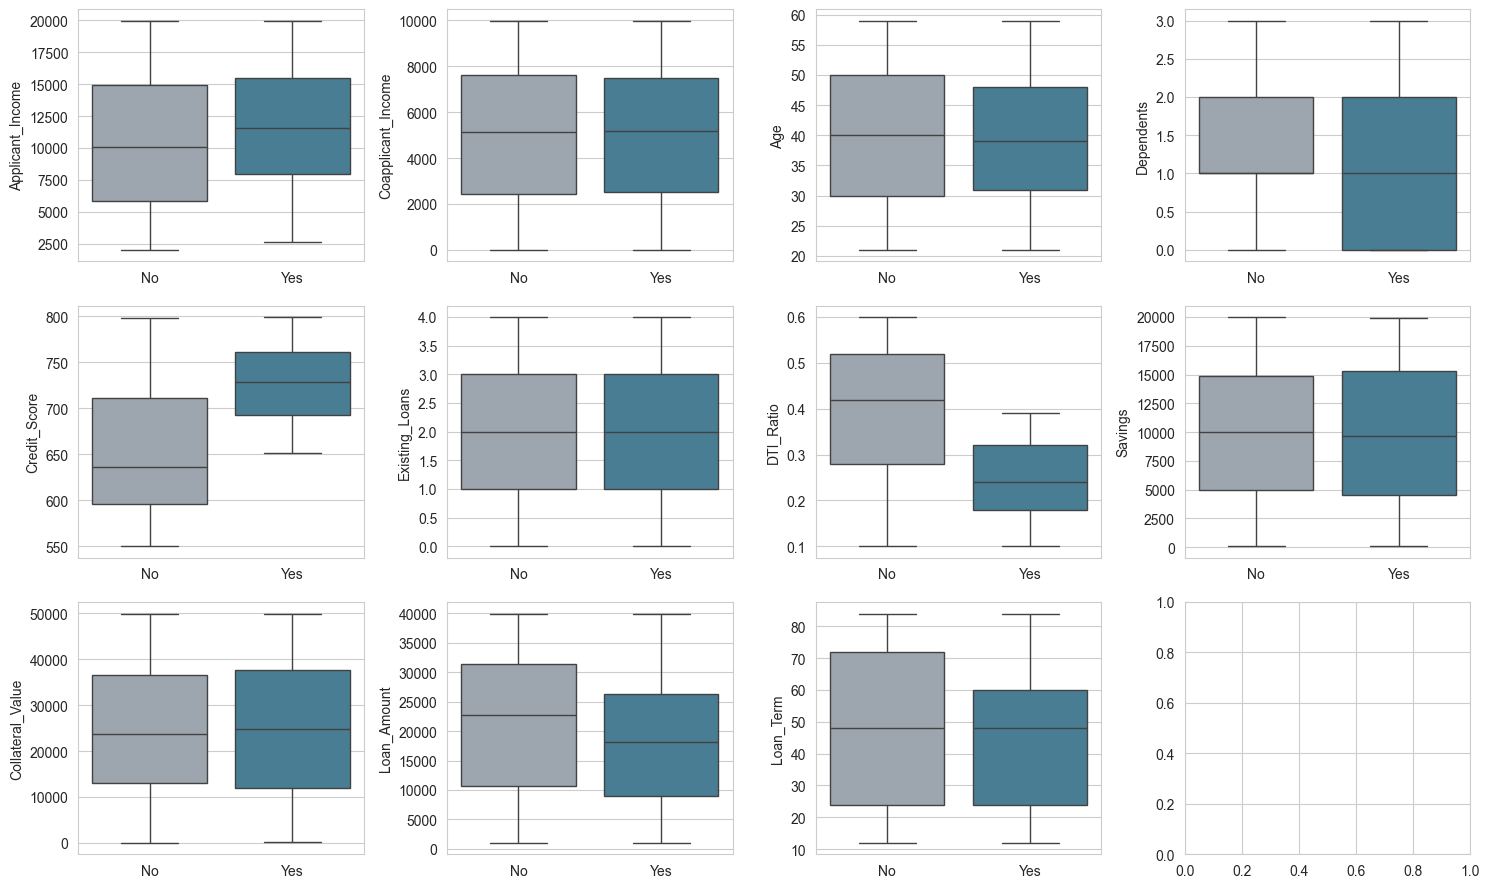

In [9]:
fig, axes = plt.subplots(3, 4, figsize=(15, 9))
for ax, col in zip(axes.flatten(), num_cols):
    sns.boxplot(data=df, x="Loan_Approved", y=col, ax=ax, palette=["#9aa5b1", "#3b82a0"])
    ax.set_xticklabels(["No", "Yes"])
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

In [10]:
# count of points outside 1.5*IQR for each numeric column
for col in num_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    n = ((df[col] < q1 - 1.5 * iqr) | (df[col] > q3 + 1.5 * iqr)).sum()
    print(f"{col:20s} {n}")

Applicant_Income     0
Coapplicant_Income   0
Age                  0
Dependents           0
Credit_Score         0
Existing_Loans       0
DTI_Ratio            0
Savings              0
Collateral_Value     0
Loan_Amount          0
Loan_Term            0


### Categorical features

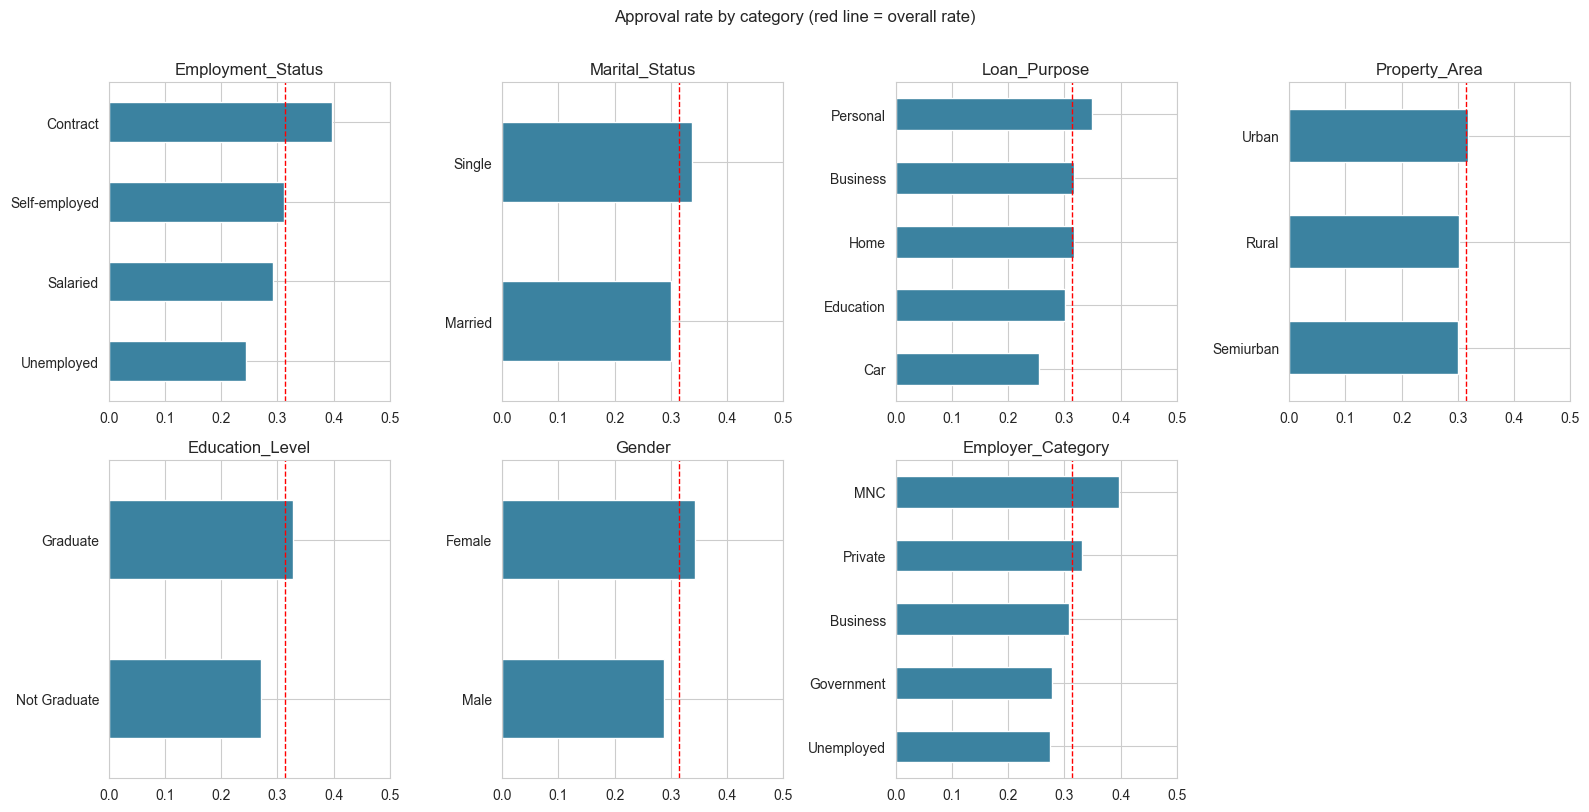

In [11]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
overall = df["Loan_Approved"].mean()

for ax, col in zip(axes.flatten(), cat_cols):
    rate = df.groupby(col)["Loan_Approved"].mean().sort_values()
    rate.plot(kind="barh", ax=ax, color="#3b82a0")
    ax.axvline(overall, color="red", linestyle="--", linewidth=1)
    ax.set_title(col)
    ax.set_ylabel("")
    ax.set_xlim(0, 0.5)

axes.flatten()[-1].axis("off")
plt.suptitle("Approval rate by category (red line = overall rate)", y=1.01)
plt.tight_layout()
plt.show()

In [12]:
# group sizes, to see how much to trust the rates above
for col in cat_cols:
    print(df[col].value_counts().to_dict())

{'Salaried': 448, 'Contract': 199, 'Self-employed': 173, 'Unemployed': 86}
{'Married': 567, 'Single': 335}
{'Car': 192, 'Business': 192, 'Home': 180, 'Personal': 169, 'Education': 169}
{'Urban': 443, 'Rural': 278, 'Semiurban': 180}
{'Graduate': 638, 'Not Graduate': 265}
{'Male': 538, 'Female': 365}
{'Private': 351, 'Government': 191, 'MNC': 136, 'Business': 130, 'Unemployed': 95}


### Correlations

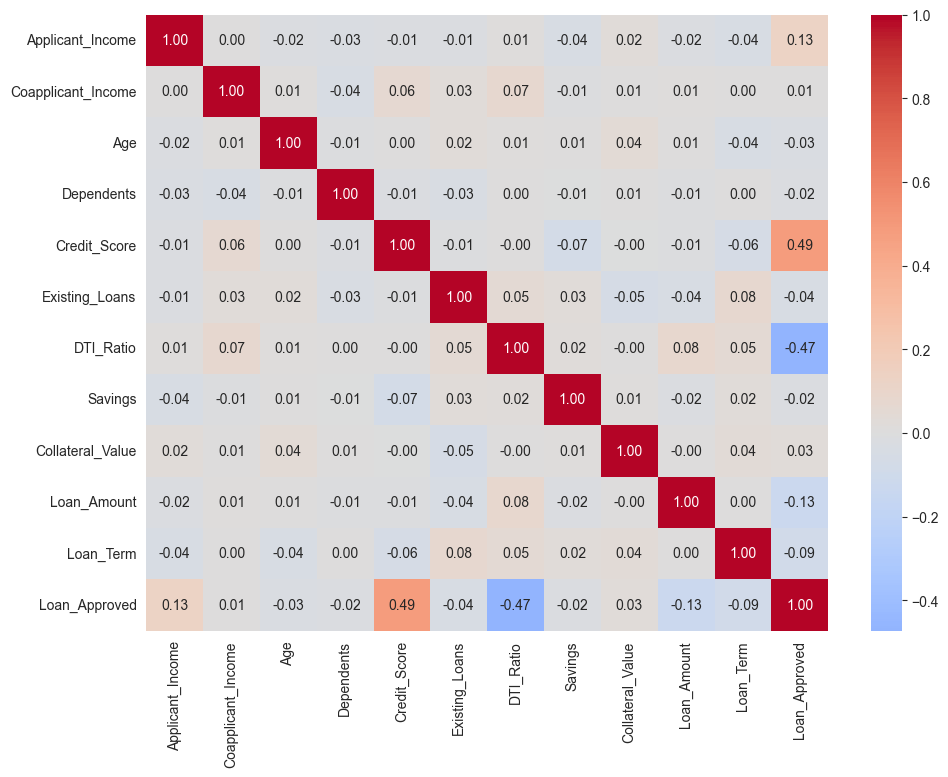

DTI_Ratio            -0.472434
Loan_Amount          -0.130477
Loan_Term            -0.092600
Existing_Loans       -0.036184
Age                  -0.028058
Savings              -0.017319
Dependents           -0.016541
Coapplicant_Income    0.009340
Collateral_Value      0.028128
Applicant_Income      0.127922
Credit_Score          0.489880
Name: Loan_Approved, dtype: float64

In [13]:
corr = df[num_cols + ["Loan_Approved"]].corr()

plt.figure(figsize=(11, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.show()

corr["Loan_Approved"].drop("Loan_Approved").sort_values()

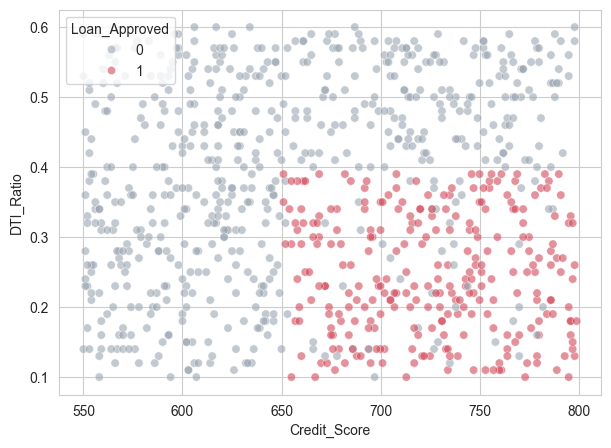

In [14]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="Credit_Score", y="DTI_Ratio", hue="Loan_Approved",
                palette=["#9aa5b1", "#d1495b"], alpha=0.6)
plt.show()

## 4. Train / test split

In [15]:
X = df.drop(columns="Loan_Approved")
y = df["Loan_Approved"]

# split first, so nothing from the test set leaks into imputing / scaling
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(X_train.shape, X_test.shape)
print(y_train.mean().round(3), y_test.mean().round(3))

(760, 18) (190, 18)
0.313 0.316


## 5. Preprocessing pipeline

In [16]:
num_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])

cat_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="if_binary", handle_unknown="ignore")),
])

preprocess = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols),
])

## 6. Baseline comparison

Seven models with default settings, scored with 5-fold stratified CV on the training set only.

In [17]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "SVM (rbf)": SVC(probability=True, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]

rows = []
for name, clf in models.items():
    pipe = Pipeline([("prep", preprocess), ("model", clf)])
    res = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring)
    row = {"model": name}
    for s in scoring:
        row[s] = res["test_" + s].mean()
    rows.append(row)

baseline = pd.DataFrame(rows).set_index("model").round(3)
baseline.sort_values("f1", ascending=False)

,accuracy,precision,recall,f1,roc_auc
model,,,,,
Gradient Boosting,0.957,0.909,0.958,0.933,0.985
Random Forest,0.939,0.907,0.899,0.902,0.982
Decision Tree,0.930,0.895,0.882,0.888,0.917
SVM (rbf),0.899,0.860,0.807,0.832,0.952
Logistic Regression,0.858,0.801,0.732,0.762,0.922
Naive Bayes,0.855,0.823,0.694,0.749,0.943
KNN,0.817,0.724,0.668,0.694,0.872


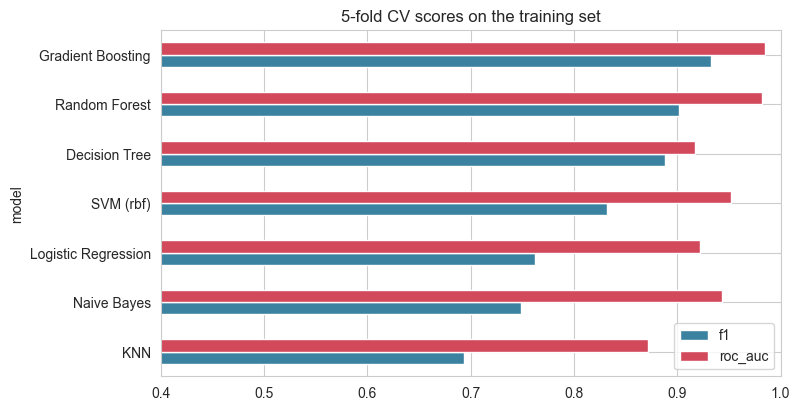

In [18]:
baseline[["f1", "roc_auc"]].sort_values("f1").plot(kind="barh", figsize=(8, 4.5), color=["#3b82a0", "#d1495b"])
plt.xlim(0.4, 1)
plt.title("5-fold CV scores on the training set")
plt.show()

## 7. Does feature engineering help?

In [19]:
# a few ratio features that a loan officer might actually look at
def add_features(data):
    data = data.copy()
    data["Total_Income"] = data["Applicant_Income"] + data["Coapplicant_Income"]
    data["Loan_to_Income"] = data["Loan_Amount"] / (data["Total_Income"] + 1)
    data["Loan_to_Collateral"] = data["Loan_Amount"] / (data["Collateral_Value"] + 1)
    data["Monthly_Payment"] = data["Loan_Amount"] / data["Loan_Term"]
    return data

X_train_fe = add_features(X_train)
num_cols_fe = X_train_fe.select_dtypes(include="number").columns.tolist()

preprocess_fe = ColumnTransformer([
    ("num", num_pipe, num_cols_fe),
    ("cat", cat_pipe, cat_cols),
])

rows = []
for name in ["Logistic Regression", "Random Forest", "Gradient Boosting"]:
    pipe = Pipeline([("prep", preprocess_fe), ("model", models[name])])
    res = cross_validate(pipe, X_train_fe, y_train, cv=cv, scoring=scoring)
    rows.append({"model": name, **{s: res["test_" + s].mean() for s in scoring}})

fe_results = pd.DataFrame(rows).set_index("model").round(3)
print("with new features")
print(fe_results)
print()
print("without")
print(baseline.loc[fe_results.index])

with new features
                     accuracy  precision  recall     f1  roc_auc
model                                                           
Logistic Regression     0.862      0.805   0.740  0.770    0.931
Random Forest           0.943      0.938   0.878  0.907    0.984
Gradient Boosting       0.957      0.905   0.962  0.933    0.986

without
                     accuracy  precision  recall     f1  roc_auc
model                                                           
Logistic Regression     0.858      0.801   0.732  0.762    0.922
Random Forest           0.939      0.907   0.899  0.902    0.982
Gradient Boosting       0.957      0.909   0.958  0.933    0.985


The changes are tiny (logistic regression gains about 0.01 F1, the others move by less than that, and not always upward). That's within CV noise, so I'm **not** keeping them.

## 8. Hyperparameter tuning

In [20]:
grids = {
    "Decision Tree": (DecisionTreeClassifier(random_state=42),
                      {"model__max_depth": [3, 4, 5, 6, 8],
                       "model__min_samples_split": [2, 10, 20, 40],
                       "model__ccp_alpha": [0, 0.001, 0.005]}),
    "Random Forest": (RandomForestClassifier(random_state=42),
                      {"model__n_estimators": [200, 400],
                       "model__max_depth": [4, 6, 10, None],
                       "model__min_samples_leaf": [1, 3, 5]}),
    "Gradient Boosting": (GradientBoostingClassifier(random_state=42),
                          {"model__n_estimators": [100, 200],
                           "model__learning_rate": [0.03, 0.1],
                           "model__max_depth": [2, 3]}),
    "Logistic Regression": (LogisticRegression(max_iter=1000),
                            {"model__C": [0.01, 0.1, 1, 10]}),
}

tuned = {}
rows = []
for name, (clf, grid) in grids.items():
    pipe = Pipeline([("prep", preprocess), ("model", clf)])
    gs = GridSearchCV(pipe, grid, cv=cv, scoring="f1", n_jobs=-1)
    gs.fit(X_train, y_train)
    tuned[name] = gs
    rows.append({"model": name, "best_cv_f1": round(gs.best_score_, 3), "best_params": gs.best_params_})

pd.DataFrame(rows).set_index("model")

,best_cv_f1,best_params
model,,
Decision Tree,0.931,"{'model__ccp_alpha': 0.005, 'model__max_depth'..."
Random Forest,0.908,"{'model__max_depth': None, 'model__min_samples..."
Gradient Boosting,0.951,"{'model__learning_rate': 0.03, 'model__max_dep..."
Logistic Regression,0.762,{'model__C': 1}


## 9. Final evaluation on the test set

In [21]:
# test set is used only here, once, for the tuned models
rows = []
for name, gs in tuned.items():
    pred = gs.predict(X_test)
    proba = gs.predict_proba(X_test)[:, 1]
    rep = classification_report(y_test, pred, output_dict=True)
    rows.append({
        "model": name,
        "accuracy": rep["accuracy"],
        "precision": rep["1"]["precision"],
        "recall": rep["1"]["recall"],
        "f1": rep["1"]["f1-score"],
        "roc_auc": roc_auc_score(y_test, proba),
    })

test_results = pd.DataFrame(rows).set_index("model").round(3)
test_results.sort_values("f1", ascending=False)

,accuracy,precision,recall,f1,roc_auc
model,,,,,
Gradient Boosting,0.963,0.908,0.983,0.944,0.987
Decision Tree,0.953,0.905,0.950,0.927,0.975
Random Forest,0.932,0.898,0.883,0.891,0.978
Logistic Regression,0.884,0.852,0.767,0.807,0.921


Gradient boosting is best on the test set too, with F1 around 0.94 and ROC-AUC around 0.99. Test and CV scores agree closely, which is a good sign that the results are not an artifact of tuning on the wrong data.

best on test: Gradient Boosting
              precision    recall  f1-score   support

    Rejected       0.99      0.95      0.97       130
    Approved       0.91      0.98      0.94        60

    accuracy                           0.96       190
   macro avg       0.95      0.97      0.96       190
weighted avg       0.97      0.96      0.96       190



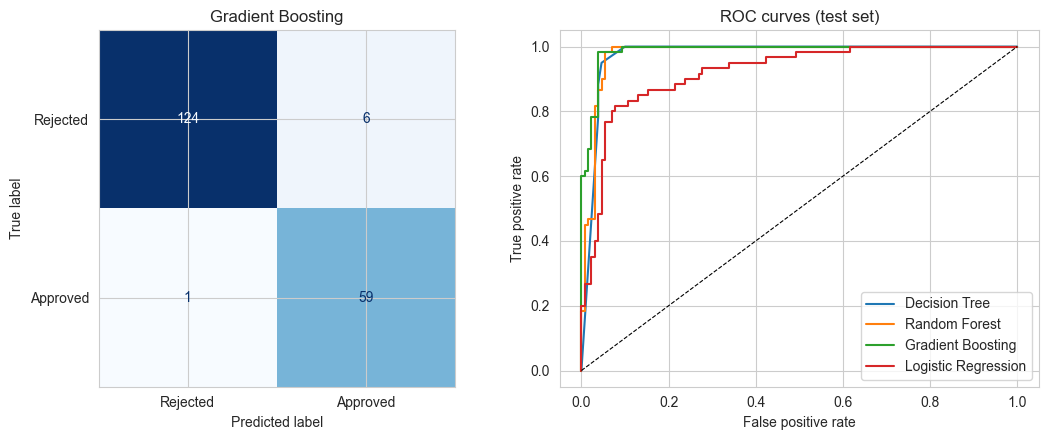

In [22]:
best_name = test_results["f1"].idxmax()
best_model = tuned[best_name]
print("best on test:", best_name)

pred = best_model.predict(X_test)
print(classification_report(y_test, pred, target_names=["Rejected", "Approved"]))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

ConfusionMatrixDisplay(confusion_matrix(y_test, pred), display_labels=["Rejected", "Approved"]).plot(
    ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title(best_name)

for name, gs in tuned.items():
    fpr, tpr, _ = roc_curve(y_test, gs.predict_proba(X_test)[:, 1])
    axes[1].plot(fpr, tpr, label=name)
axes[1].plot([0, 1], [0, 1], "k--", linewidth=0.8)
axes[1].set_xlabel("False positive rate")
axes[1].set_ylabel("True positive rate")
axes[1].legend()
axes[1].set_title("ROC curves (test set)")
plt.tight_layout()
plt.show()

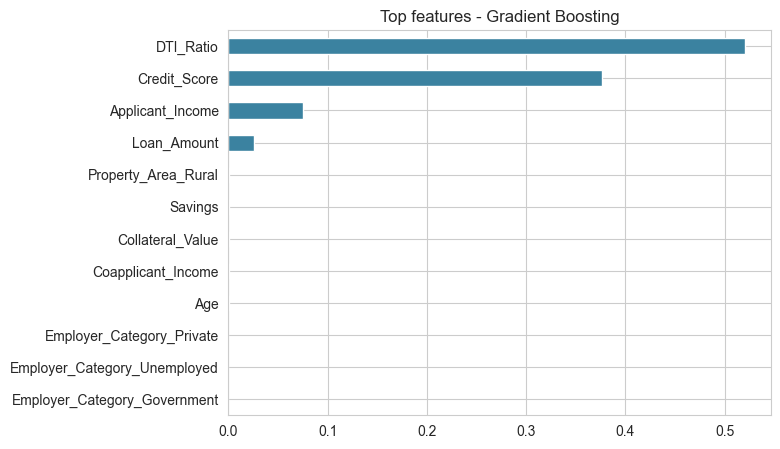

In [23]:
fitted = best_model.best_estimator_
feat_names = fitted.named_steps["prep"].get_feature_names_out()
est = fitted.named_steps["model"]

if hasattr(est, "feature_importances_"):
    imp = pd.Series(est.feature_importances_, index=feat_names)
else:
    imp = pd.Series(np.abs(est.coef_[0]), index=feat_names)

imp = imp.sort_values().tail(12)
imp.index = [i.replace("num__", "").replace("cat__", "") for i in imp.index]

imp.plot(kind="barh", figsize=(7, 5), color="#3b82a0")
plt.title(f"Top features - {best_name}")
plt.show()

### Choosing a cutoff

Banks usually care more about approving a bad loan than about turning down a good one.

In [24]:
# default cutoff is 0.5, but a bank may care more about one type of error.
# checking what happens to precision / recall if we move it
proba = best_model.predict_proba(X_test)[:, 1]

rows = []
for t in [0.3, 0.4, 0.5, 0.6, 0.7]:
    p = (proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, p).ravel()
    rows.append({"threshold": t, "precision": tp / (tp + fp), "recall": tp / (tp + fn),
                 "bad_approvals(FP)": fp, "missed_good(FN)": fn})

pd.DataFrame(rows).set_index("threshold").round(3)

,precision,recall,bad_approvals(FP),missed_good(FN)
threshold,,,,
0.3,0.843,0.983,11,1
0.4,0.881,0.983,8,1
0.5,0.908,0.983,6,1
0.6,0.922,0.983,5,1
0.7,0.917,0.917,5,5


## 10. Conclusion

- Best model: tuned gradient boosting, test F1 ≈ 0.94, ROC-AUC ≈ 0.99
- Approval is driven almost entirely by credit score and DTI ratio
- Linear models and KNN struggle because the decision boundary is rule-like
- Fixed from my first version: target rows imputed as "No", hyperparameters chosen on the test set, preprocessing before the split

**Limitations**
- The data looks synthetic: evenly spread features, no outliers, and a clean threshold-style rule behind the labels. A real loan dataset would be messier, so these scores would not carry over.
- 950 rows is small, so the test metrics have wide error bars.
- No cost-sensitive evaluation, because I don't have real costs for the two error types.

**Possible next steps:** try class weights, calibrate probabilities, compare with XGBoost/LightGBM, and wrap the saved model in a small Streamlit app.

In [25]:
joblib.dump(best_model.best_estimator_, "loan_model.joblib")

['loan_model.joblib']